In [1]:
TARGET_COL = 'H3N2_proxy_d28'  # task 4.2 (proxy for missing Massachusetts strain)

# Task 4.2

**4.2 predict magnitude of antibody response - H3N2 A/Massachusetts/18/2022 (D28)**
* Training Data: Demographics + Day 0 + Day 7 innate
* Assay: HAI
* Measure: Single strain titer
* Metric: Spearman correlation
* Full description: HAI titer for H3N2 A/Massachusetts/18/2022 at Day 28

## Task 4.2: Focus
Magnitude refers to the strength of the antibody response against a single specific vaccine strain.
We are predicting the HAI titer for H3N2 A/Massachusetts/18/2022 at Day 28 post-vaccination.

In [2]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.pipeline import Pipeline
from data_cleaning.utils import peek

In [3]:
DATA_PATH = 'cleaned_data'
train_participants = pd.read_csv(DATA_PATH + '/participants_cleaned.csv')
train_hai = pd.read_csv(DATA_PATH + '/hai_cleaned.csv')

In [4]:
for name, df in {'train_hai': train_hai, 'train_participants': train_participants}.items():
    print(f"\n{'=' * 50}")
    print(f'TABLE: {name}')
    print(f"{'=' * 50}")
    display(peek(df))


TABLE: train_hai


,participant_id,HAI_Anc B/Lee/1940_d0,HAI_Anc B/Lee/1940_d28,HAI_Anc B/Lee/1940_d365,HAI_Anc B/Maryland/1959_d0,HAI_Anc B/Maryland/1959_d28,HAI_Anc B/Singapore/1964_d0,HAI_Anc B/Singapore/1964_d28,HAI_H1N1 A/Beijing/262/1995_d0,HAI_H1N1 A/Beijing/262/1995_d28,HAI_H1N1 A/Beijing/262/1995_d365,HAI_H1N1 A/Brazil/11/1978_d0,HAI_H1N1 A/Brazil/11/1978_d28,HAI_H1N1 A/Brazil/11/1978_d365,HAI_H1N1 A/Brisbane/2/2018_d0,HAI_H1N1 A/Brisbane/2/2018_d28,HAI_H1N1 A/Brisbane/2/2018_d365,HAI_H1N1 A/Brisbane/59/2007_d0,HAI_H1N1 A/Brisbane/59/2007_d28,HAI_H1N1 A/Brisbane/59/2007_d365
0,2016_UGA.ID_001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.321928,5.321928,NaN,2.321928,2.321928,NaN,NaN,NaN,NaN,3.321928,5.321928,NaN
1,2016_UGA.ID_002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.321928,5.321928,NaN,2.321928,2.321928,NaN,NaN,NaN,NaN,5.321928,5.321928,NaN
2,2016_UGA.ID_003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.321928,5.321928,NaN,2.321928,2.321928,NaN,NaN,NaN,NaN,3.321928,3.321928,NaN
3,2016_UGA.ID_004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.321928,5.321928,NaN,2.321928,2.321928,NaN,NaN,NaN,NaN,3.321928,5.321928,NaN
4,2016_UGA.ID_005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.321928,2.321928,2.321928,2.321928,2.321928,2.321928,NaN,NaN,NaN,2.321928,2.321928,3.321928



TABLE: train_participants


,participant_id,PART_biological_sex,PART_race,PART_geolocation,PART_arm_name,PART_age
0,SDY269.SUB112836,Female,White,Georgia,Other,28.0
1,SDY269.SUB112849,Female,Black,Georgia,Other,39.0
2,SDY269.SUB112854,Male,Black,Georgia,Other,46.0
3,SDY269.SUB112860,Female,White,Georgia,Other,32.0
4,SDY269.SUB112881,Female,Black,Georgia,Other,29.0


### Data is pre-cleaned
Both tables are already one row per participant with cleaned column names:
- HAI columns follow `HAI_{strain}_d{timepoint}` format
- Participant columns follow `PART_{field}` format

We just need to merge them and separate features from target.

In [5]:
# Merge HAI and participant tables
data = train_hai.merge(train_participants, on='participant_id', how='inner')
print(f'Merged shape: {data.shape}')
peek(data)

Merged shape: (3757, 201)


,participant_id,HAI_Anc B/Lee/1940_d0,HAI_Anc B/Lee/1940_d28,HAI_Anc B/Lee/1940_d365,HAI_Anc B/Maryland/1959_d0,HAI_Anc B/Maryland/1959_d28,HAI_Anc B/Singapore/1964_d0,HAI_Anc B/Singapore/1964_d28,HAI_H1N1 A/Beijing/262/1995_d0,HAI_H1N1 A/Beijing/262/1995_d28,HAI_H1N1 A/Beijing/262/1995_d365,HAI_H1N1 A/Brazil/11/1978_d0,HAI_H1N1 A/Brazil/11/1978_d28,HAI_H1N1 A/Brazil/11/1978_d365,HAI_H1N1 A/Brisbane/2/2018_d0,HAI_H1N1 A/Brisbane/2/2018_d28,HAI_H1N1 A/Brisbane/2/2018_d365,HAI_H1N1 A/Brisbane/59/2007_d0,HAI_H1N1 A/Brisbane/59/2007_d28,HAI_H1N1 A/Brisbane/59/2007_d365
0,2016_UGA.ID_001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.321928,5.321928,NaN,2.321928,2.321928,NaN,NaN,NaN,NaN,3.321928,5.321928,NaN
1,2016_UGA.ID_002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.321928,5.321928,NaN,2.321928,2.321928,NaN,NaN,NaN,NaN,5.321928,5.321928,NaN
2,2016_UGA.ID_003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.321928,5.321928,NaN,2.321928,2.321928,NaN,NaN,NaN,NaN,3.321928,3.321928,NaN
3,2016_UGA.ID_004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.321928,5.321928,NaN,2.321928,2.321928,NaN,NaN,NaN,NaN,3.321928,5.321928,NaN
4,2016_UGA.ID_005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.321928,2.321928,2.321928,2.321928,2.321928,2.321928,NaN,NaN,NaN,2.321928,2.321928,3.321928


In [6]:
# 1. Create a proxy target for H3N2 Day 28 by averaging all historical H3N2 Day 28 titers
h3n2_d28_cols = [c for c in data.columns if 'H3N2' in c and c.endswith('_d28')]
data['H3N2_proxy_d28'] = data[h3n2_d28_cols].mean(axis=1)
TARGET_COL = 'H3N2_proxy_d28'

# 2. Features: demographic + d0 columns for ALL H3N2 strains
feature_cols = [c for c in data.columns
                if c != 'participant_id'
                and c != TARGET_COL
                and (not c.startswith('HAI_') or ('H3N2' in c and c.endswith('_d0')))]

print(f'Target: {TARGET_COL} (Created from {len(h3n2_d28_cols)} H3N2 strains)')
print(f'Features: {len(feature_cols)}')
print(f'Sample feature names: {feature_cols[:5]}')
print(f'HAI features kept: {[c for c in feature_cols if c.startswith("HAI_")]}')

Target: H3N2_proxy_d28 (Created from 25 H3N2 strains)
Features: 30
Sample feature names: ['HAI_H3N2 A/Brisbane/10/2007_d0', 'HAI_H3N2 A/Darwin/9/2021_d0', 'HAI_H3N2 A/Hong Kong/1/1968_d0', 'HAI_H3N2 A/Hong Kong/2671/2019_d0', 'HAI_H3N2 A/Hong Kong/4801/2014_d0']
HAI features kept: ['HAI_H3N2 A/Brisbane/10/2007_d0', 'HAI_H3N2 A/Darwin/9/2021_d0', 'HAI_H3N2 A/Hong Kong/1/1968_d0', 'HAI_H3N2 A/Hong Kong/2671/2019_d0', 'HAI_H3N2 A/Hong Kong/4801/2014_d0', 'HAI_H3N2 A/Kansas/14/2017_d0', 'HAI_H3N2 A/Mississippi/1/1985_d0', 'HAI_H3N2 A/Nanchang/933/1995_d0', 'HAI_H3N2 A/New York/55/2004_d0', 'HAI_H3N2 A/Panama/2007/1999_d0', 'HAI_H3N2 A/Perth/16/2009_d0', 'HAI_H3N2 A/Port Chalmers/1/1973_d0', 'HAI_H3N2 A/Shandong/9/1993_d0', 'HAI_H3N2 A/Sichuan/60/1989_d0', 'HAI_H3N2 A/Singapore/INFIMH-160019/2016_d0', 'HAI_H3N2 A/South Australia/34/2019_d0', 'HAI_H3N2 A/Switzerland/9715293/2013_d0', 'HAI_H3N2 A/Sydney/5/1997_d0', 'HAI_H3N2 A/Tasmania/503/2020_d0', 'HAI_H3N2 A/Texas/1/1977_d0', 'HAI_H3N2 A/T

/var/folders/kp/4mhl7j_j6354gqcs12nt1y680000gn/T/ipykernel_27172/3718124639.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['H3N2_proxy_d28'] = data[h3n2_d28_cols].mean(axis=1)


### Build X and y

In [7]:
# Target: single strain HAI titer at Day 28
y_vals = data[TARGET_COL].copy()

# Drop rows where target is NaN
mask = y_vals.notna()
y_vals = y_vals[mask]
X = data.loc[mask, feature_cols].copy()

# Log-transform target (standard practice for HAI titers)
y_vals = np.log1p(y_vals)

print(f'Samples: {len(X)}')
print(f'Features: {X.shape[1]}')

Samples: 3568
Features: 30


### Encode categorical features

In [8]:
# One-hot encode any categorical PART_ columns
cat_cols = X.select_dtypes(include='object').columns.tolist()
if cat_cols:
    print(f'Encoding categorical columns: {cat_cols}')
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print(f'Final feature count: {X.shape[1]}')

Encoding categorical columns: ['PART_biological_sex', 'PART_race', 'PART_geolocation', 'PART_arm_name']
Final feature count: 41


/var/folders/kp/4mhl7j_j6354gqcs12nt1y680000gn/T/ipykernel_27172/398821456.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include='object').columns.tolist()


In [9]:
peek(X)

,HAI_H3N2 A/Brisbane/10/2007_d0,HAI_H3N2 A/Darwin/9/2021_d0,HAI_H3N2 A/Hong Kong/1/1968_d0,HAI_H3N2 A/Hong Kong/2671/2019_d0,HAI_H3N2 A/Hong Kong/4801/2014_d0,HAI_H3N2 A/Kansas/14/2017_d0,HAI_H3N2 A/Mississippi/1/1985_d0,HAI_H3N2 A/Nanchang/933/1995_d0,HAI_H3N2 A/New York/55/2004_d0,HAI_H3N2 A/Panama/2007/1999_d0,HAI_H3N2 A/Perth/16/2009_d0,HAI_H3N2 A/Port Chalmers/1/1973_d0,HAI_H3N2 A/Shandong/9/1993_d0,HAI_H3N2 A/Sichuan/60/1989_d0,HAI_H3N2 A/Singapore/INFIMH-160019/2016_d0,HAI_H3N2 A/South Australia/34/2019_d0,HAI_H3N2 A/Switzerland/9715293/2013_d0,HAI_H3N2 A/Sydney/5/1997_d0,HAI_H3N2 A/Tasmania/503/2020_d0,HAI_H3N2 A/Texas/1/1977_d0
0,NaN,NaN,3.321928,NaN,5.321928,NaN,6.321928,7.321928,6.321928,6.321928,4.321928,3.321928,7.321928,7.321928,NaN,NaN,4.321928,6.321928,NaN,4.321928
1,NaN,NaN,4.321928,NaN,5.321928,NaN,7.321928,6.321928,7.321928,5.321928,5.321928,3.321928,6.321928,6.321928,NaN,NaN,7.321928,6.321928,NaN,4.321928
2,NaN,NaN,3.321928,NaN,6.321928,NaN,3.321928,8.321928,10.321928,8.321928,7.321928,3.321928,8.321928,8.321928,NaN,NaN,5.321928,8.321928,NaN,4.321928
3,NaN,NaN,2.321928,NaN,4.321928,NaN,2.321928,4.321928,3.321928,4.321928,3.321928,2.321928,2.321928,2.321928,NaN,NaN,2.321928,3.321928,NaN,2.321928
4,NaN,NaN,2.321928,NaN,7.321928,NaN,2.321928,2.321928,8.321928,7.321928,8.321928,2.321928,3.321928,3.321928,NaN,NaN,7.321928,7.321928,NaN,2.321928


### Train model

**Why Spearman correlation?**

This task uses Spearman correlation as its evaluation metric. Spearman only cares about
**rankings**. It converts all your true values and predictions into ranks (1st, 2nd, 3rd…)
and then checks whether those two rank orderings agree.

This is a good fit for antibody data because:
- HAI titers are noisy and vary across studies, so predicting exact values is unrealistic.
- What matters clinically is *relative* response: can we identify who will respond well vs. poorly?
- Spearman is also robust to outliers and non-linear relationships — if your predictions are
  monotonically related to the truth (always going in the right direction), Spearman rewards that
  even if the relationship isn't a straight line.

**Interpreting the score:**
A Spearman of 1.0 means perfect ranking agreement, 0.0 means no relationship, and -1.0 means
perfectly reversed rankings.

In [10]:
# Simple pipeline: impute remaining NaNs, then regress
model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('regressor', LinearRegression())
])

# --- Cross-validated evaluation (the real score) ---
cv = KFold(n_splits=5, shuffle=True, random_state=42)
y_pred_cv = cross_val_predict(model, X, y_vals, cv=cv)
rho_cv, pval_cv = spearmanr(y_vals, y_pred_cv)
print(f'Spearman (5-fold CV): {rho_cv:.3f}  (p-value: {pval_cv:.4f})')

Spearman (5-fold CV): 0.744  (p-value: 0.0000)


### Why Cross-Validation?

The CV score above is our real evaluation. Each participant's prediction was made by a model
that **never saw that participant during training** (5-fold: train on 4/5 of the data, predict
the held-out 1/5, rotate). This tells us how the model would perform on new, unseen participants.

The train score is shown only as an overfitting diagnostic — a large gap between train and CV
means the model memorised noise rather than learning real patterns.

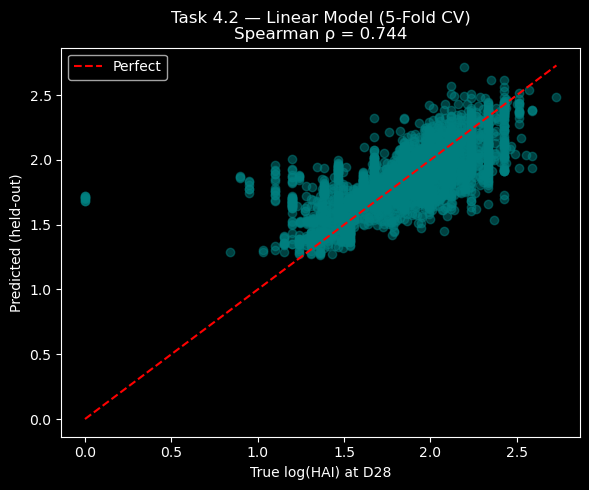

In [11]:
plt.figure(figsize=(6, 5))
plt.scatter(y_vals, y_pred_cv, alpha=0.5, color='teal')
plt.plot([y_vals.min(), y_vals.max()], [y_vals.min(), y_vals.max()], 'r--', label='Perfect')
plt.xlabel('True log(HAI) at D28')
plt.ylabel('Predicted (held-out)')
plt.title(f'Task 4.2 — Linear Model (5-Fold CV)\nSpearman ρ = {rho_cv:.3f}')
plt.legend()
plt.tight_layout()
plt.show()

### Predict on Challenge Set (Task 4.2)
Now we load the unseen challenge data, align its features with our training set, train our model on all available training data, and generate final predictions.

In [12]:
# Load challenge data
challenge_participants = pd.read_csv(DATA_PATH + '/challenge_participants_cleaned.csv')
challenge_hai = pd.read_csv(DATA_PATH + '/challenge_hai_cleaned.csv')
challenge_data = challenge_hai.merge(challenge_participants, on='participant_id', how='inner')

# Extract only the features that exist in the challenge data
existing_cols = [c for c in ['participant_id'] + feature_cols if c in challenge_data.columns]
X_challenge = challenge_data[existing_cols].copy()
challenge_ids = X_challenge.pop('participant_id')

# One-hot encode using the same categorical columns (if they exist in challenge data)
challenge_cat_cols = [c for c in cat_cols if c in X_challenge.columns]
if challenge_cat_cols:
    X_challenge = pd.get_dummies(X_challenge, columns=challenge_cat_cols, drop_first=True)

# Align columns exactly with the training set X
# - Drops columns found in challenge but not in training
# - Adds columns found in training but not in challenge as NaN
# The SimpleImputer in our pipeline will safely fill these NaNs with the training median!
X_challenge = X_challenge.reindex(columns=X.columns)

# Fit the model on 100% of the training data
model.fit(X, y_vals)

# Generate predictions
preds_4_2 = model.predict(X_challenge)

# Save to DataFrame (reverse log1p transform)
challenge_results_4_2 = pd.DataFrame({
    'Participant_ID': challenge_ids,
    'Task_4.2': np.expm1(preds_4_2)
})

os.makedirs('submission', exist_ok=True)
print(f"Generated {len(challenge_results_4_2)} predictions for Task 4.2 Challenge Set.")
challenge_results_4_2.to_csv('submission/task_4_2.csv', index=False)
peek(challenge_results_4_2)

Generated 40 predictions for Task 4.2 Challenge Set.


,Participant_ID,Task_4.2
0,2024_UGA.ID_077,3.376643
1,2024_UGA.ID_086,2.631090
2,2024_UGA.ID_128,5.447734
3,2024_UGA.ID_170,3.514049
4,2024_UGA.ID_179,3.132028


---
# Task 4.8

**4.8 predict antibody durability - H3N2 A/Massachusetts/18/2022 (D365)**
* Training Data: Demographics + Day 0
* Assay: HAI
* Measure: Post-vac HAI
* Metric: Spearman correlation
* Full description: Post-vac HAI of the H3N2 vaccine strain at Day 365

## Task 4.8: Focus
Durability refers to the antibody titer at Day 365 post-vaccination.
We are predicting the HAI titer for H3N2 A/Massachusetts/18/2022 at Day 365. Since the exact strain is missing, we use the same H3N2 proxy strategy to create `H3N2_proxy_d365`.

In [13]:
# 1. Create a proxy target for H3N2 Day 365 by averaging all historical H3N2 Day 365 titers
h3n2_d365_cols = [c for c in data.columns if 'H3N2' in c and c.endswith('_d365')]
data['H3N2_proxy_d365'] = data[h3n2_d365_cols].mean(axis=1)
TARGET_COL_4_8 = 'H3N2_proxy_d365'

# 2. Features: demographic + d0 columns for ALL H3N2 strains
feature_cols_4_8 = [c for c in data.columns
                    if c != 'participant_id'
                    and 'proxy' not in c
                    and (not c.startswith('HAI_') or ('H3N2' in c and c.endswith('_d0')))]

print(f'Target: {TARGET_COL_4_8} (Created from {len(h3n2_d365_cols)} H3N2 strains)')
print(f'Features: {len(feature_cols_4_8)}')
print(f'Sample feature names: {feature_cols_4_8[:5]}')
print(f'HAI features kept: {[c for c in feature_cols_4_8 if c.startswith("HAI_")]}')

Target: H3N2_proxy_d365 (Created from 23 H3N2 strains)
Features: 30
Sample feature names: ['HAI_H3N2 A/Brisbane/10/2007_d0', 'HAI_H3N2 A/Darwin/9/2021_d0', 'HAI_H3N2 A/Hong Kong/1/1968_d0', 'HAI_H3N2 A/Hong Kong/2671/2019_d0', 'HAI_H3N2 A/Hong Kong/4801/2014_d0']
HAI features kept: ['HAI_H3N2 A/Brisbane/10/2007_d0', 'HAI_H3N2 A/Darwin/9/2021_d0', 'HAI_H3N2 A/Hong Kong/1/1968_d0', 'HAI_H3N2 A/Hong Kong/2671/2019_d0', 'HAI_H3N2 A/Hong Kong/4801/2014_d0', 'HAI_H3N2 A/Kansas/14/2017_d0', 'HAI_H3N2 A/Mississippi/1/1985_d0', 'HAI_H3N2 A/Nanchang/933/1995_d0', 'HAI_H3N2 A/New York/55/2004_d0', 'HAI_H3N2 A/Panama/2007/1999_d0', 'HAI_H3N2 A/Perth/16/2009_d0', 'HAI_H3N2 A/Port Chalmers/1/1973_d0', 'HAI_H3N2 A/Shandong/9/1993_d0', 'HAI_H3N2 A/Sichuan/60/1989_d0', 'HAI_H3N2 A/Singapore/INFIMH-160019/2016_d0', 'HAI_H3N2 A/South Australia/34/2019_d0', 'HAI_H3N2 A/Switzerland/9715293/2013_d0', 'HAI_H3N2 A/Sydney/5/1997_d0', 'HAI_H3N2 A/Tasmania/503/2020_d0', 'HAI_H3N2 A/Texas/1/1977_d0', 'HAI_H3N2 A/

/var/folders/kp/4mhl7j_j6354gqcs12nt1y680000gn/T/ipykernel_27172/3959657806.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['H3N2_proxy_d365'] = data[h3n2_d365_cols].mean(axis=1)


### Build X and y for Task 4.8

In [14]:
# Target: single strain HAI titer at Day 365
y_vals_4_8 = data[TARGET_COL_4_8].copy()

# Drop rows where target is NaN
mask_4_8 = y_vals_4_8.notna()
y_vals_4_8 = y_vals_4_8[mask_4_8]
X_4_8 = data.loc[mask_4_8, feature_cols_4_8].copy()

# Log-transform target (standard practice for HAI titers)
y_vals_4_8 = np.log1p(y_vals_4_8)

print(f'Samples: {len(X_4_8)}')
print(f'Features: {X_4_8.shape[1]}')

Samples: 990
Features: 30


### Encode categorical features for Task 4.8

In [15]:
# One-hot encode any categorical PART_ columns
cat_cols_4_8 = X_4_8.select_dtypes(include='object').columns.tolist()
if cat_cols_4_8:
    print(f'Encoding categorical columns: {cat_cols_4_8}')
    X_4_8 = pd.get_dummies(X_4_8, columns=cat_cols_4_8, drop_first=True)
print(f'Final feature count: {X_4_8.shape[1]}')

Encoding categorical columns: ['PART_biological_sex', 'PART_race', 'PART_geolocation', 'PART_arm_name']
Final feature count: 28


/var/folders/kp/4mhl7j_j6354gqcs12nt1y680000gn/T/ipykernel_27172/2858867607.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_4_8 = X_4_8.select_dtypes(include='object').columns.tolist()


### Train model and evaluate (Task 4.8)

In [16]:
# Simple pipeline: impute remaining NaNs, then regress
model_4_8 = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('regressor', LinearRegression())
])

# --- Cross-validated evaluation (the real score) ---
cv_4_8 = KFold(n_splits=5, shuffle=True, random_state=42)
y_pred_cv_4_8 = cross_val_predict(model_4_8, X_4_8, y_vals_4_8, cv=cv_4_8)
rho_cv_4_8, pval_cv_4_8 = spearmanr(y_vals_4_8, y_pred_cv_4_8)
print(f'Spearman (5-fold CV): {rho_cv_4_8:.3f}  (p-value: {pval_cv_4_8:.4f})')

Spearman (5-fold CV): 0.855  (p-value: 0.0000)


/Users/chayan/anaconda3/envs/cmi-flu-prediction-challenge-capstone/lib/python3.13/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['HAI_H3N2 A/Brisbane/10/2007_d0' 'HAI_H3N2 A/Victoria/3/1975_d0']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/chayan/anaconda3/envs/cmi-flu-prediction-challenge-capstone/lib/python3.13/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['HAI_H3N2 A/Brisbane/10/2007_d0' 'HAI_H3N2 A/Victoria/3/1975_d0']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/chayan/anaconda3/envs/cmi-flu-prediction-challenge-capstone/lib/python3.13/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['HAI_H3N2 A/Brisbane/10/2007_d0' 'HAI_H3N2 A/Victoria/3/1975_d0']. At least one non-missing value is needed for im

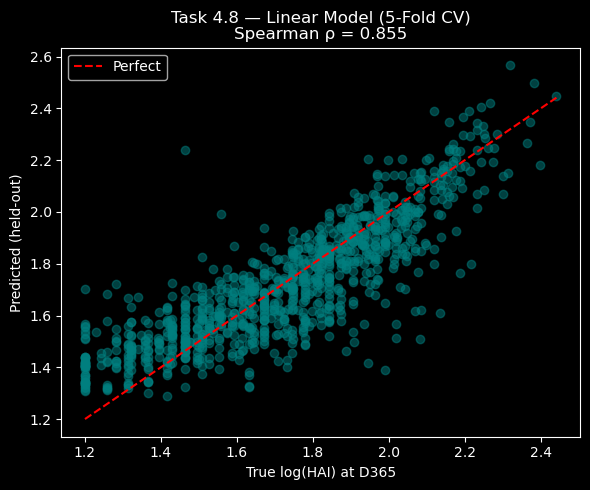

In [17]:
plt.figure(figsize=(6, 5))
plt.scatter(y_vals_4_8, y_pred_cv_4_8, alpha=0.5, color='teal')
plt.plot([y_vals_4_8.min(), y_vals_4_8.max()], [y_vals_4_8.min(), y_vals_4_8.max()], 'r--', label='Perfect')
plt.xlabel('True log(HAI) at D365')
plt.ylabel('Predicted (held-out)')
plt.title(f'Task 4.8 — Linear Model (5-Fold CV)\nSpearman ρ = {rho_cv_4_8:.3f}')
plt.legend()
plt.tight_layout()
plt.show()

### Predict on Challenge Set (Task 4.8)
Now we generate final predictions for Day 365 using the same dynamic column alignment.

In [18]:
# Extract only the features that exist in the challenge data
existing_cols_4_8 = [c for c in ['participant_id'] + feature_cols_4_8 if c in challenge_data.columns]
X_challenge_4_8 = challenge_data[existing_cols_4_8].copy()
challenge_ids_4_8 = X_challenge_4_8.pop('participant_id')

# One-hot encode using the same categorical columns
challenge_cat_cols_4_8 = [c for c in cat_cols_4_8 if c in X_challenge_4_8.columns]
if challenge_cat_cols_4_8:
    X_challenge_4_8 = pd.get_dummies(X_challenge_4_8, columns=challenge_cat_cols_4_8, drop_first=True)

# Align columns exactly with the training set X_4_8
X_challenge_4_8 = X_challenge_4_8.reindex(columns=X_4_8.columns)

# Fit the model on 100% of the training data
model_4_8.fit(X_4_8, y_vals_4_8)

# Generate predictions
preds_4_8 = model_4_8.predict(X_challenge_4_8)

# Save to DataFrame (reverse log1p transform)
challenge_results_4_8 = pd.DataFrame({
    'Participant_ID': challenge_ids_4_8,
    'Task_4.8': np.expm1(preds_4_8)
})

os.makedirs('submission', exist_ok=True)
print(f"Generated {len(challenge_results_4_8)} predictions for Task 4.8 Challenge Set.")
challenge_results_4_8.to_csv('submission/task_4_8.csv', index=False)
peek(challenge_results_4_8)

Generated 40 predictions for Task 4.8 Challenge Set.


/Users/chayan/anaconda3/envs/cmi-flu-prediction-challenge-capstone/lib/python3.13/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['HAI_H3N2 A/Brisbane/10/2007_d0' 'HAI_H3N2 A/Victoria/3/1975_d0']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/chayan/anaconda3/envs/cmi-flu-prediction-challenge-capstone/lib/python3.13/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['HAI_H3N2 A/Brisbane/10/2007_d0' 'HAI_H3N2 A/Victoria/3/1975_d0']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


,Participant_ID,Task_4.8
0,2024_UGA.ID_077,4.323135
1,2024_UGA.ID_086,3.476545
2,2024_UGA.ID_128,7.982906
3,2024_UGA.ID_170,4.953778
4,2024_UGA.ID_179,4.034311
